In [1]:
# Cell 1: Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import zipfile
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve)

# For hyperparameter tuning
from scipy.stats import uniform, randint

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Cell 2: Create directory for saving figures
figures_dir = '/kaggle/working/figures'  # Path inside Kaggle environment
# figures_dir = 'figures'  # Uncomment this line if running locally

if not os.path.exists(figures_dir):
    os.makedirs(figures_dir)
    print(f"Folder '{figures_dir}' created successfully!")
else:
    print(f"Folder '{figures_dir}' already exists.")
    

Folder '/kaggle/working/figures' created successfully!


In [3]:
# Cell 3: Load the Heart Disease dataset using ucimlrepo (official UCI method)
# Install the package if not already installed
!pip install ucimlrepo -q

from ucimlrepo import fetch_ucirepo

# Fetch dataset using correct ID (45 for Heart Disease)
heart_disease = fetch_ucirepo(id=45)

# Data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets

# Combine features and target into one DataFrame
df = pd.concat([X, y], axis=1)

# Rename the target column (last column)
df.rename(columns={df.columns[-1]: 'target'}, inplace=True)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

# Check for missing values
print(f"\nMissing values:\n{df.isnull().sum()}")


Dataset shape: (303, 14)

First 5 rows:

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB

=== Missing Values ===
      Missing  Percentage
ca          4    1.320132
thal        2    0.660066

=== Target Distribution (Binary) ===
target
0    164
1    139
Name: count, dtype: int64
Percent

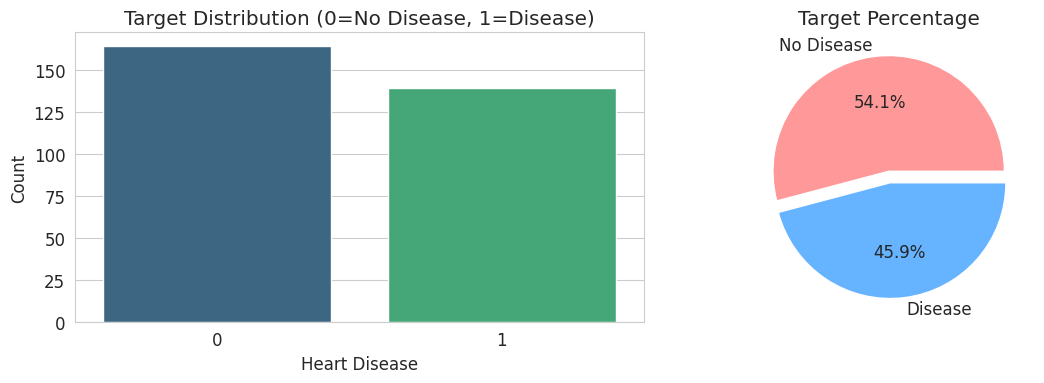

In [4]:
# Cell 4: Basic info and missing values analysis with figure saving
print("=== Dataset Info ===")
df.info()

print("\n=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing'] > 0])

print("\n=== Target Distribution (Binary) ===")
# Convert to binary: 0 = no disease, 1-4 = disease
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)
target_counts = df['target'].value_counts()
print(target_counts)
print(f"Percentage with heart disease: {target_counts[1]/len(df)*100:.2f}%")

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x='target', ax=axes[0], palette='viridis')
axes[0].set_title('Target Distribution (0=No Disease, 1=Disease)')
axes[0].set_xlabel('Heart Disease')
axes[0].set_ylabel('Count')

axes[1].pie(target_counts, labels=['No Disease', 'Disease'], autopct='%1.1f%%', 
            colors=['#ff9999','#66b3ff'], explode=(0.05, 0.05))
axes[1].set_title('Target Percentage')
plt.tight_layout()

# Save figure
figure_filename = os.path.join(figures_dir, 'target_distribution.png')
plt.savefig(figure_filename, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {figure_filename}")

plt.show()

Figure 2 saved to: /kaggle/working/figures/figure2_class_distribution.png


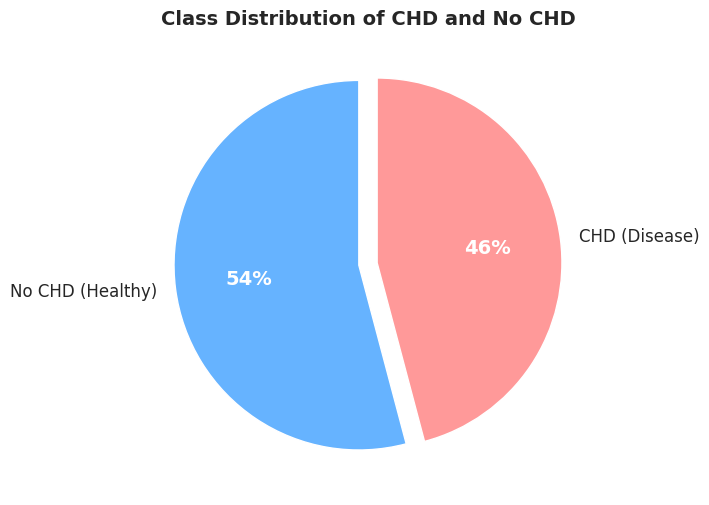

Figure 3 saved to: /kaggle/working/figures/figure3_numerical_distributions.png


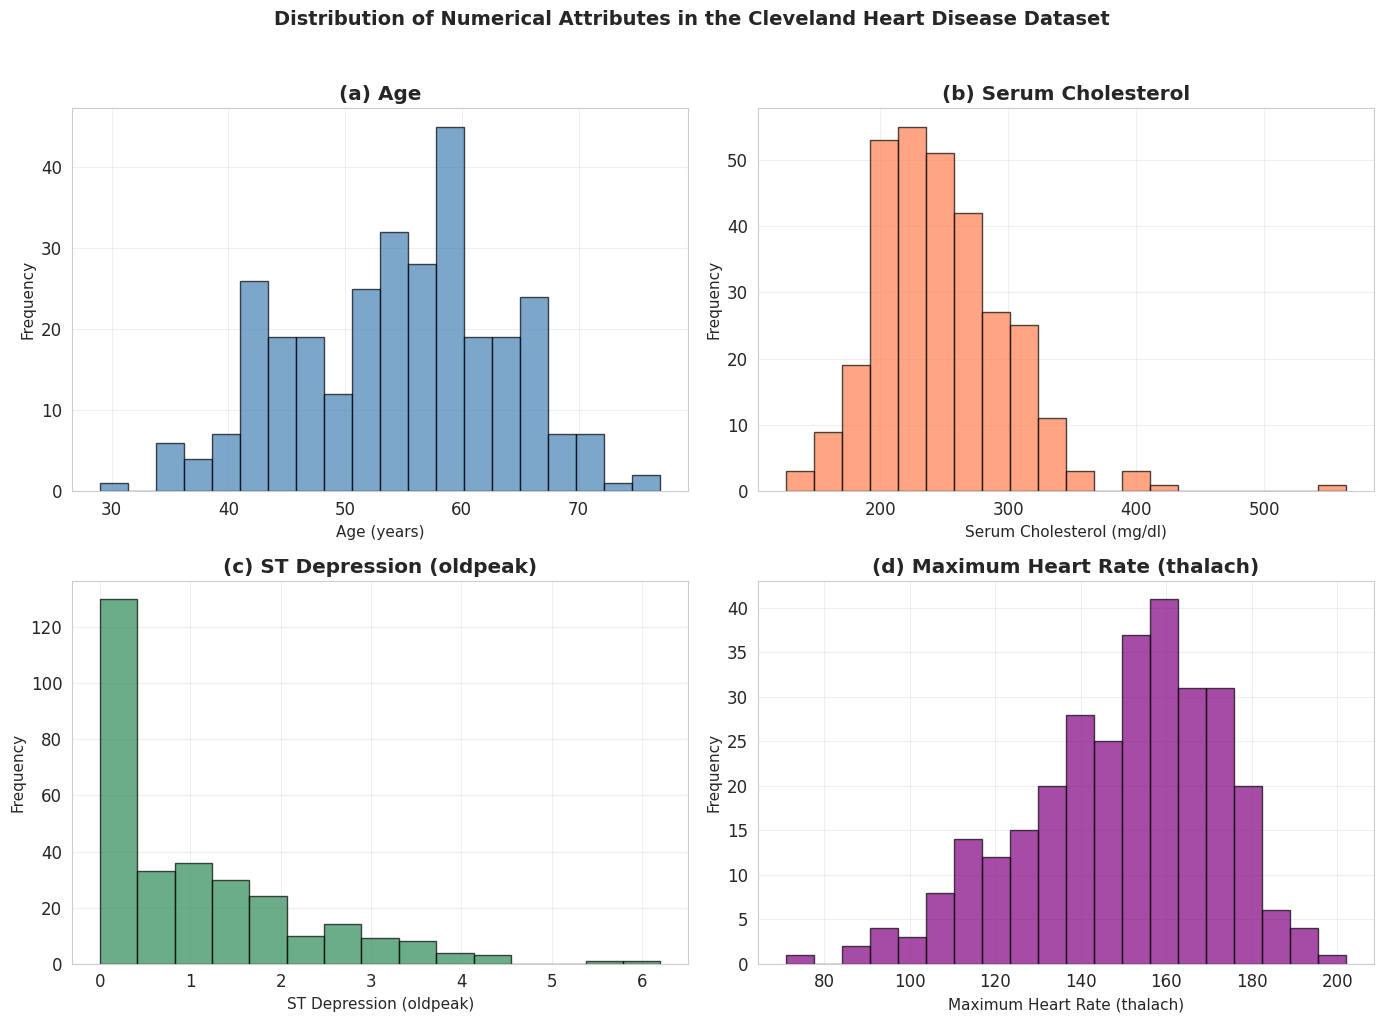

In [5]:
# Cell 4.5: Create Figure 2 and Figure 3 for the paper

# ============================================
# FIGURE 2: Class Distribution (Pie Chart)
# ============================================
fig2, ax = plt.subplots(figsize=(8, 6))
target_counts = df['target'].value_counts()
colors_pie = ['#66b3ff', '#ff9999']
labels_pie = ['No CHD (Healthy)', 'CHD (Disease)']

wedges, texts, autotexts = ax.pie(target_counts, labels=labels_pie, autopct='%1.0f%%',
                                    colors=colors_pie, startangle=90, explode=(0.05, 0.05),
                                    textprops={'fontsize': 12})
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(14)

ax.set_title('Class Distribution of CHD and No CHD', fontsize=14, fontweight='bold')

# Save Figure 2
fig2_filename = os.path.join(figures_dir, 'figure2_class_distribution.png')
plt.savefig(fig2_filename, dpi=300, bbox_inches='tight')
print(f"Figure 2 saved to: {fig2_filename}")
plt.show()

# ============================================
# FIGURE 3: Distribution of numerical attributes (4 subplots)
# ============================================
fig3, axes = plt.subplots(2, 2, figsize=(14, 10))
fig3.suptitle('Distribution of Numerical Attributes in the Cleveland Heart Disease Dataset', 
              fontsize=14, fontweight='bold', y=1.02)

# (a) Age distribution
axes[0, 0].hist(df['age'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Age (years)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('(a) Age', fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# (b) Serum cholesterol distribution
axes[0, 1].hist(df['chol'], bins=20, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Serum Cholesterol (mg/dl)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('(b) Serum Cholesterol', fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# (c) ST depression (oldpeak) distribution
axes[1, 0].hist(df['oldpeak'], bins=15, color='seagreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('ST Depression (oldpeak)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('(c) ST Depression (oldpeak)', fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# (d) Maximum heart rate (thalach) distribution
axes[1, 1].hist(df['thalach'], bins=20, color='purple', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Maximum Heart Rate (thalach)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('(d) Maximum Heart Rate (thalach)', fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()

# Save Figure 3
fig3_filename = os.path.join(figures_dir, 'figure3_numerical_distributions.png')
plt.savefig(fig3_filename, dpi=300, bbox_inches='tight')
print(f"Figure 3 saved to: {fig3_filename}")
plt.show()

=== Statistical Summary ===
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.438944    0.679868    3.158416  131.689769  246.693069    0.148515   
std      9.038662    0.467299    0.960126   17.599748   51.776918    0.356198   
min     29.000000    0.000000    1.000000   94.000000  126.000000    0.000000   
25%     48.000000    0.000000    3.000000  120.000000  211.000000    0.000000   
50%     56.000000    1.000000    3.000000  130.000000  241.000000    0.000000   
75%     61.000000    1.000000    4.000000  140.000000  275.000000    0.000000   
max     77.000000    1.000000    4.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  299.000000   
mean     0.990099  149.607261    0.326733    1.039604    1.600660    0.672241   

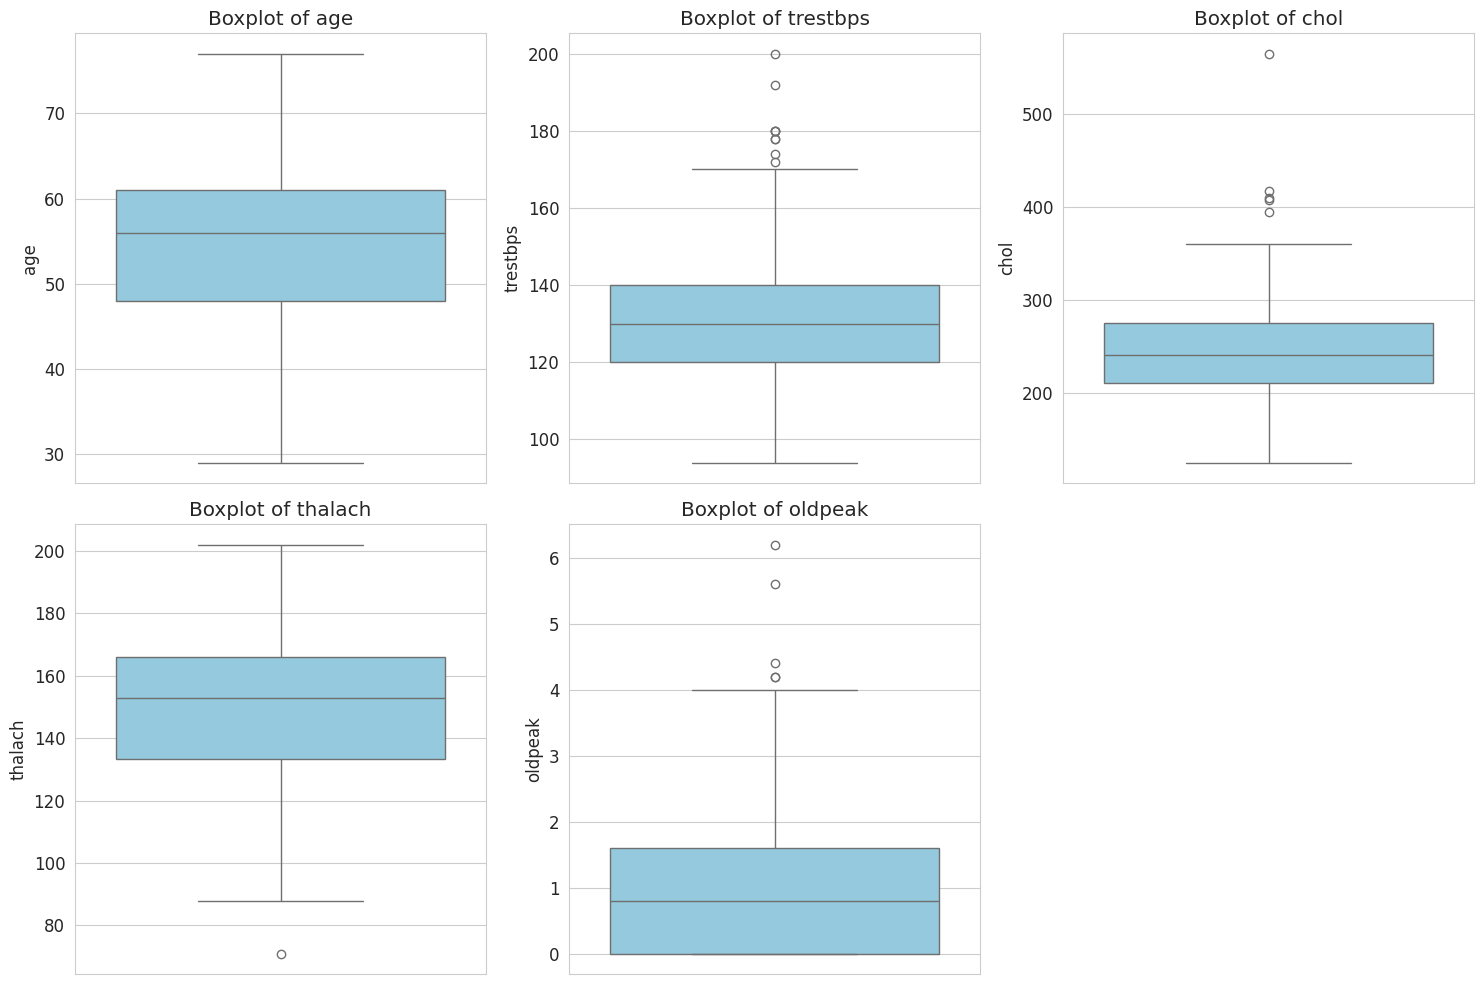

In [6]:
# Cell 5: Statistical summary and outlier visualization with figure saving
print("=== Statistical Summary ===")
print(df.describe())

# Visualize outliers using boxplots for numerical features
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {col}')
    
    # Calculate outliers using IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers detected")

# Remove the last empty subplot if any
if len(numerical_cols) < 6:
    fig.delaxes(axes[-1])

plt.tight_layout()

# Save figure
figure_filename = os.path.join(figures_dir, 'outlier_boxplots.png')
plt.savefig(figure_filename, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {figure_filename}")

plt.show()

Figure saved to: /kaggle/working/figures/correlation_matrix.png


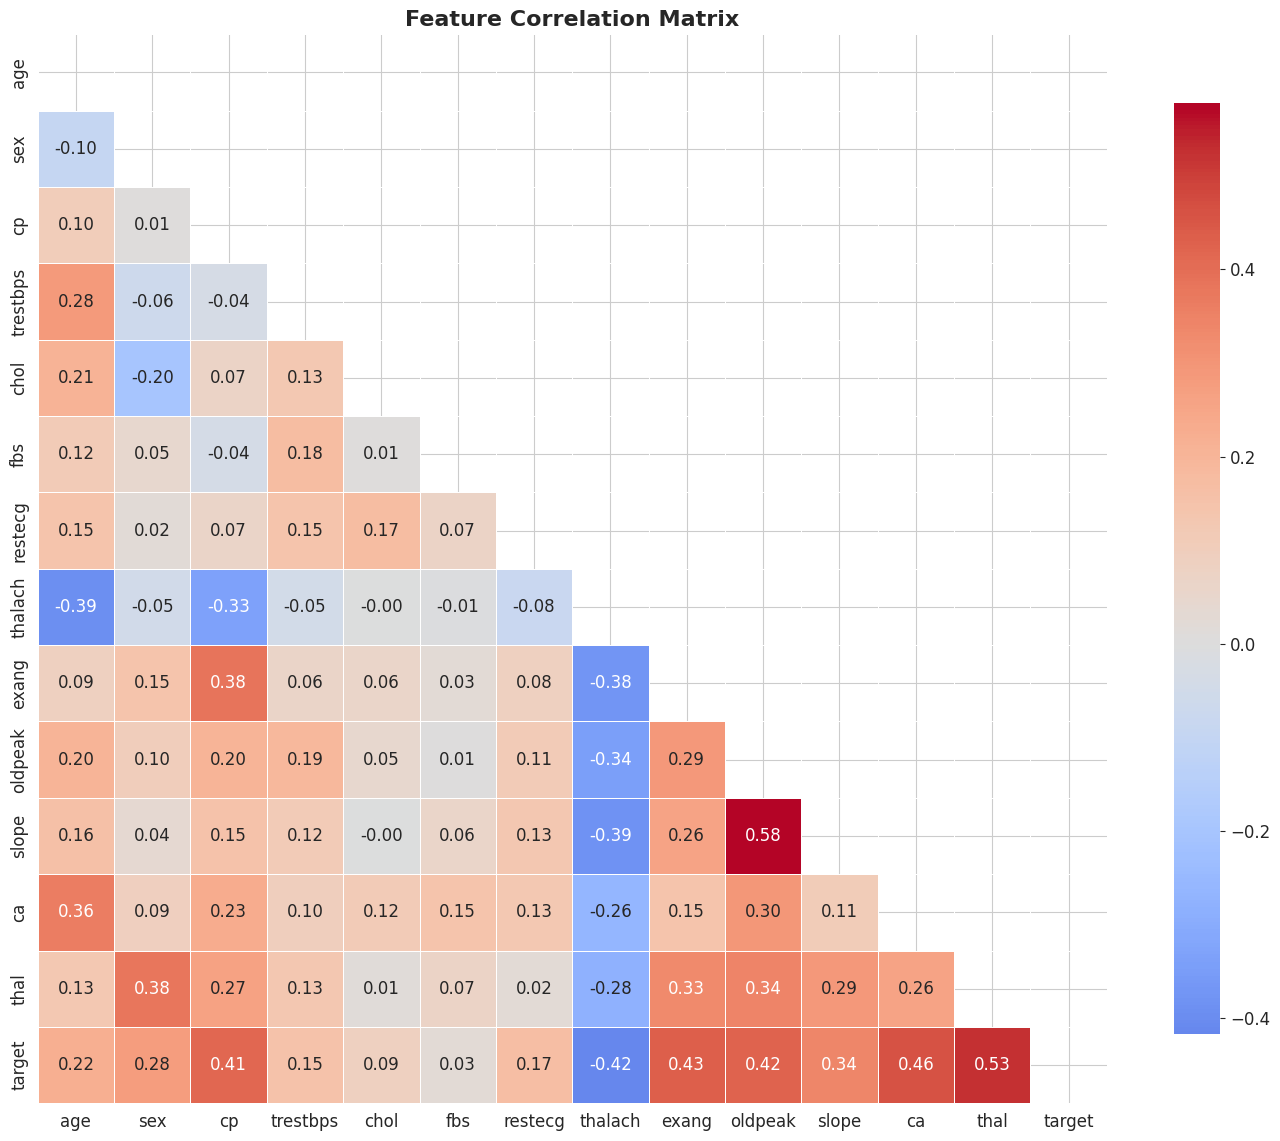


=== Features Correlated with Target ===
target      1.000000
thal        0.525689
ca          0.460442
exang       0.431894
oldpeak     0.424510
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264
thalach    -0.417167
Name: target, dtype: float64
Figure saved to: /kaggle/working/figures/pairplot_top_features.png


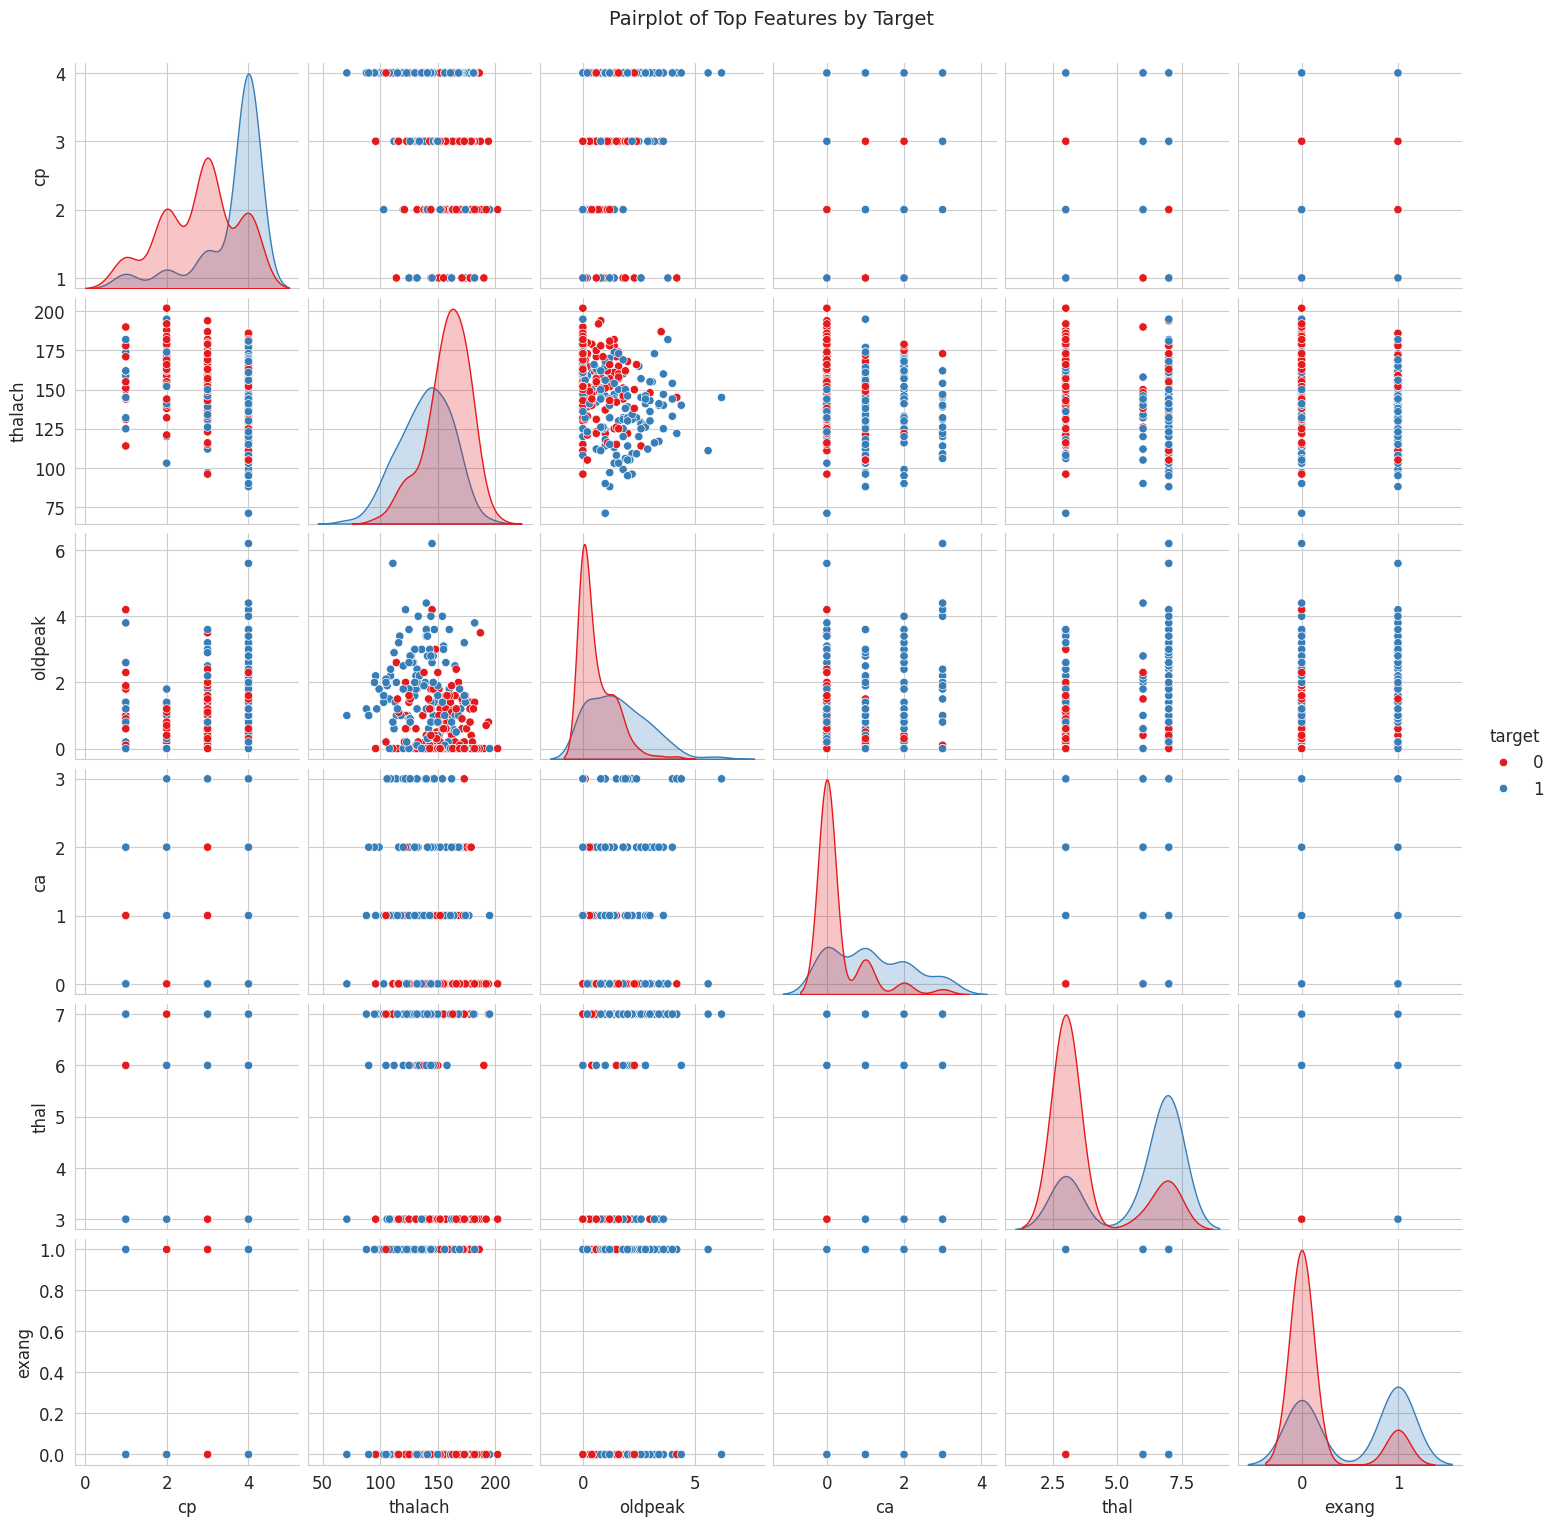

In [7]:
# Cell 6: Correlation analysis and feature relationships with figure saving
# Correlation matrix
plt.figure(figsize=(14, 12))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()

# Save figure
figure_filename = os.path.join(figures_dir, 'correlation_matrix.png')
plt.savefig(figure_filename, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {figure_filename}")

plt.show()

# Most correlated features with target
corr_with_target = corr_matrix['target'].sort_values(ascending=False)
print("\n=== Features Correlated with Target ===")
print(corr_with_target)

# Pairplot for top features (this one takes time, save separately)
top_features = ['target', 'cp', 'thalach', 'oldpeak', 'ca', 'thal', 'exang']
pairplot_fig = sns.pairplot(df[top_features], hue='target', diag_kind='kde', palette='Set1')
pairplot_fig.fig.suptitle('Pairplot of Top Features by Target', y=1.02, fontsize=14)

# Save pairplot
figure_filename = os.path.join(figures_dir, 'pairplot_top_features.png')
pairplot_fig.savefig(figure_filename, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {figure_filename}")

plt.show()

In [8]:
# Cell 7: Handle missing values and create new features
print("=== Missing values before handling ===")
print(df.isnull().sum())

# 'ca' and 'thal' have missing values
# Fill with mode (most frequent)
df['ca'] = df['ca'].fillna(df['ca'].mode()[0])
df['thal'] = df['thal'].fillna(df['thal'].mode()[0])

# Verify no missing values remain
print("\n=== Missing values after handling ===")
print(df.isnull().sum())

# Feature Engineering
# 1. Age groups
df['age_group'] = pd.cut(df['age'], bins=[0, 40, 50, 60, 100], labels=['<40', '40-50', '50-60', '60+'])

# 2. Blood pressure categories
df['bp_category'] = pd.cut(df['trestbps'], bins=[0, 120, 130, 140, 200], 
                           labels=['Normal', 'Elevated', 'High Stage1', 'High Stage2'])

# 3. Interaction features
df['age_chol_interaction'] = df['age'] * df['chol'] / 1000
df['bp_hr_interaction'] = df['trestbps'] * df['thalach'] / 1000

# 4. Oldpeak categories
df['oldpeak_category'] = pd.cut(df['oldpeak'], bins=[-1, 0.5, 1.5, 10], 
                                labels=['Low', 'Medium', 'High'])

print("\n=== New features created ===")
print(df[['age_group', 'bp_category', 'oldpeak_category']].head())

# Encode categorical features
df_encoded = pd.get_dummies(df, columns=['age_group', 'bp_category', 'oldpeak_category'], drop_first=True)
print(f"\nShape after encoding: {df_encoded.shape}")

=== Missing values before handling ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

=== Missing values after handling ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

=== New features created ===
  age_group  bp_category oldpeak_category
0       60+  High Stage2             High
1       60+  High Stage2           Medium
2       60+       Normal             High
3       <40     Elevated             High
4     40-50     Elevated           Medium

Shape after encoding: (303, 24)


In [9]:
# Cell 8: Split features and target, then scale
# Prepare features and target
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

# Identify numerical columns for scaling (exclude dummy columns)
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'age_chol_interaction', 'bp_hr_interaction']
categorical_dummies = [col for col in X.columns if col not in numerical_features + ['ca', 'thal', 'slope', 'cp', 'restecg', 'sex', 'fbs', 'exang']]

print(f"Numerical features: {numerical_features}")
print(f"Categorical/dummy features: {len(categorical_dummies)} features")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Training target distribution:\n{y_train.value_counts(normalize=True)}")

# Scale numerical features
scaler = RobustScaler()  # Robust to outliers
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

print("\nScaling completed using RobustScaler")

Numerical features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'age_chol_interaction', 'bp_hr_interaction']
Categorical/dummy features: 8 features

Training set size: (242, 23)
Test set size: (61, 23)
Training target distribution:
target
0    0.541322
1    0.458678
Name: proportion, dtype: float64

Scaling completed using RobustScaler


In [10]:
# Cell 9: Baseline Models Comparison with Cross-Validation

from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_val_predict
from sklearn.base import clone
from sklearn.metrics import accuracy_score, recall_score, f1_score
import pandas as pd
import numpy as np

# Define all 9 models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(random_state=42, probability=True),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

print("=" * 60)
print("Running 5-Fold Cross-Validation on Training Set (n=242)")
print("=" * 60)

# Perform 5-fold cross-validation for AUC
cv_results = []
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
    cv_results.append({
        'Model': name,
        'Mean AUC': cv_scores.mean(),
        'Std AUC': cv_scores.std()
    })
    print(f"{name:20s} -> AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Convert to DataFrame and sort
cv_df = pd.DataFrame(cv_results).sort_values('Mean AUC', ascending=False)

print("\n" + "=" * 60)
print("=== 5-Fold Cross-Validation ROC-AUC Scores (Sorted) ===")
print("=" * 60)
print(cv_df.to_string(index=False))

# ============================================
# Also calculate Accuracy, Recall, F1 using cross-validation
# ============================================
print("\n" + "=" * 60)
print("Calculating Accuracy, Recall, and F1 Scores (5-Fold CV)")
print("=" * 60)

accuracy_means = []
accuracy_stds = []
recall_means = []
recall_stds = []
f1_means = []
f1_stds = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    acc_scores = []
    recall_scores = []
    f1_scores = []
    
    for train_idx, val_idx in skf.split(X_train_scaled, y_train):
        X_fold_train = X_train_scaled.iloc[train_idx]
        X_fold_val = X_train_scaled.iloc[val_idx]
        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]
        
        model_clone = clone(model)
        model_clone.fit(X_fold_train, y_fold_train)
        y_fold_pred = model_clone.predict(X_fold_val)
        
        acc_scores.append(accuracy_score(y_fold_val, y_fold_pred))
        recall_scores.append(recall_score(y_fold_val, y_fold_pred))
        f1_scores.append(f1_score(y_fold_val, y_fold_pred))
    
    accuracy_means.append(np.mean(acc_scores))
    accuracy_stds.append(np.std(acc_scores))
    recall_means.append(np.mean(recall_scores))
    recall_stds.append(np.std(recall_scores))
    f1_means.append(np.mean(f1_scores))
    f1_stds.append(np.std(f1_scores))
    
    print(f"{name:20s} -> Acc: {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f} | Recall: {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f} | F1: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")

# Create results dataframe for all metrics
model_names_list = list(models.keys())
all_metrics_df = pd.DataFrame({
    'Model': model_names_list,
    'AUC_Mean': [cv_results[i]['Mean AUC'] for i in range(len(models))],
    'AUC_Std': [cv_results[i]['Std AUC'] for i in range(len(models))],
    'Acc_Mean': accuracy_means,
    'Acc_Std': accuracy_stds,
    'Recall_Mean': recall_means,
    'Recall_Std': recall_stds,
    'F1_Mean': f1_means,
    'F1_Std': f1_stds
})

print("\n" + "=" * 60)
print("Complete Cross-Validation Results Summary (5-Fold)")
print("=" * 60)
print(all_metrics_df.round(4).to_string(index=False))

# Save metrics for Cell 9.5
cv_auc_means = [cv_results[i]['Mean AUC'] for i in range(len(models))]
cv_auc_stds = [cv_results[i]['Std AUC'] for i in range(len(models))]
cv_acc_means = accuracy_means
cv_acc_stds = accuracy_stds
cv_recall_means = recall_means
cv_recall_stds = recall_stds
cv_f1_means = f1_means
cv_f1_stds = f1_stds

print("\n✅ Cross-validation complete! Results stored for Figure 4.")

Running 5-Fold Cross-Validation on Training Set (n=242)
Logistic Regression  -> AUC: 0.8809 ± 0.0519
SVM                  -> AUC: 0.8769 ± 0.0417
KNN                  -> AUC: 0.8643 ± 0.0385
Decision Tree        -> AUC: 0.6980 ± 0.0280
Random Forest        -> AUC: 0.8659 ± 0.0433
AdaBoost             -> AUC: 0.8714 ± 0.0517
Gradient Boosting    -> AUC: 0.8570 ± 0.0558
XGBoost              -> AUC: 0.8646 ± 0.0384
LightGBM             -> AUC: 0.8643 ± 0.0487

=== 5-Fold Cross-Validation ROC-AUC Scores (Sorted) ===
              Model  Mean AUC  Std AUC
Logistic Regression  0.880877 0.051945
                SVM  0.876949 0.041665
           AdaBoost  0.871424 0.051679
      Random Forest  0.865921 0.043348
            XGBoost  0.864565 0.038362
           LightGBM  0.864295 0.048730
                KNN  0.864279 0.038521
  Gradient Boosting  0.856990 0.055773
      Decision Tree  0.698042 0.028015

Calculating Accuracy, Recall, and F1 Scores (5-Fold CV)
Logistic Regression  -> Acc: 0.8181

Creating Figure 4 with YOUR ACTUAL RESULTS:
Models: ['LR', 'SVM', 'KNN', 'DT', 'RF', 'AdaBoost', 'GB', 'XGBoost', 'LGBM']
AUC means: [0.8809, 0.8769, 0.8643, 0.698, 0.8659, 0.8714, 0.857, 0.8646, 0.8643]
Accuracy means: [0.8181, 0.8058, 0.8016, 0.7105, 0.7851, 0.7933, 0.7894, 0.781, 0.7934]
Recall means: [0.7739, 0.7561, 0.7474, 0.702, 0.7379, 0.7656, 0.7656, 0.7565, 0.7561]
F1 means: [0.7939, 0.7785, 0.7735, 0.6885, 0.7585, 0.7713, 0.7691, 0.7602, 0.7692]

✅ Figure 4 saved to: /kaggle/working/figures/figure4_performance_metrics.png


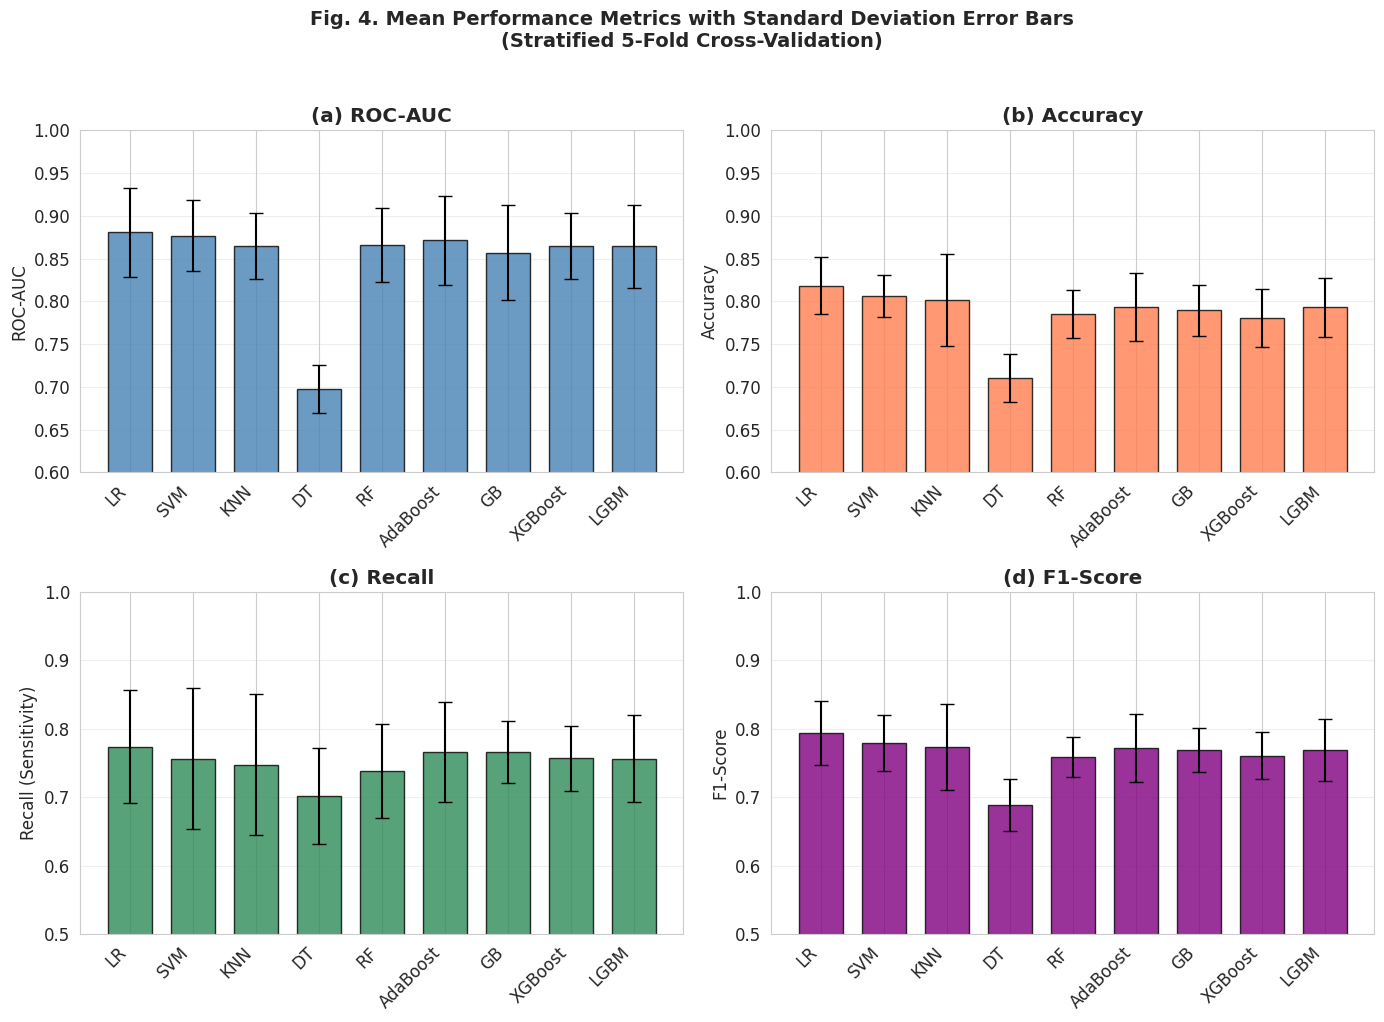


✅ Figure 4 created successfully with your actual results!


In [11]:
# Cell 9.5: Create Figure 4 - Mean performance metrics with error bars
# Using YOUR ACTUAL cross-validation results from Cell 9

import matplotlib.pyplot as plt
import numpy as np
import os

# ============================================
# YOUR ACTUAL RESULTS FROM CELL 9
# ============================================

models = ['LR', 'SVM', 'KNN', 'DT', 'RF', 'AdaBoost', 'GB', 'XGBoost', 'LGBM']

# AUC results (from Cell 9)
auc_means = [0.8809, 0.8769, 0.8643, 0.6980, 0.8659, 0.8714, 0.8570, 0.8646, 0.8643]
auc_stds = [0.0519, 0.0417, 0.0385, 0.0280, 0.0433, 0.0517, 0.0558, 0.0384, 0.0487]

# Accuracy results (from Cell 9)
accuracy_means = [0.8181, 0.8058, 0.8016, 0.7105, 0.7851, 0.7933, 0.7894, 0.7810, 0.7934]
accuracy_stds = [0.0334, 0.0246, 0.0536, 0.0281, 0.0282, 0.0398, 0.0297, 0.0340, 0.0345]

# Recall results (from Cell 9)
recall_means = [0.7739, 0.7561, 0.7474, 0.7020, 0.7379, 0.7656, 0.7656, 0.7565, 0.7561]
recall_stds = [0.0827, 0.1031, 0.1026, 0.0702, 0.0688, 0.0731, 0.0451, 0.0473, 0.0633]

# F1 results (from Cell 9)
f1_means = [0.7939, 0.7785, 0.7735, 0.6885, 0.7585, 0.7713, 0.7691, 0.7602, 0.7692]
f1_stds = [0.0467, 0.0408, 0.0629, 0.0375, 0.0298, 0.0496, 0.0322, 0.0344, 0.0453]

print("=" * 60)
print("Creating Figure 4 with YOUR ACTUAL RESULTS:")
print("=" * 60)
print(f"Models: {models}")
print(f"AUC means: {auc_means}")
print(f"Accuracy means: {accuracy_means}")
print(f"Recall means: {recall_means}")
print(f"F1 means: {f1_means}")

# ============================================
# Create the figure
# ============================================
fig4, axes = plt.subplots(2, 2, figsize=(14, 10))
fig4.suptitle('Fig. 4. Mean Performance Metrics with Standard Deviation Error Bars\n(Stratified 5-Fold Cross-Validation)', 
              fontsize=14, fontweight='bold', y=1.02)

x = np.arange(len(models))
width = 0.7

# Plot 1: ROC-AUC
axes[0, 0].bar(x, auc_means, width, yerr=auc_stds, capsize=5, color='steelblue', alpha=0.8, edgecolor='black')
axes[0, 0].set_ylabel('ROC-AUC', fontsize=12)
axes[0, 0].set_title('(a) ROC-AUC', fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models, rotation=45, ha='right')
axes[0, 0].set_ylim([0.6, 1.0])
axes[0, 0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
axes[0, 0].grid(alpha=0.3, axis='y')

# Plot 2: Accuracy
axes[0, 1].bar(x, accuracy_means, width, yerr=accuracy_stds, capsize=5, color='coral', alpha=0.8, edgecolor='black')
axes[0, 1].set_ylabel('Accuracy', fontsize=12)
axes[0, 1].set_title('(b) Accuracy', fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models, rotation=45, ha='right')
axes[0, 1].set_ylim([0.6, 1.0])
axes[0, 1].grid(alpha=0.3, axis='y')

# Plot 3: Recall
axes[1, 0].bar(x, recall_means, width, yerr=recall_stds, capsize=5, color='seagreen', alpha=0.8, edgecolor='black')
axes[1, 0].set_ylabel('Recall (Sensitivity)', fontsize=12)
axes[1, 0].set_title('(c) Recall', fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(models, rotation=45, ha='right')
axes[1, 0].set_ylim([0.5, 1.0])
axes[1, 0].grid(alpha=0.3, axis='y')

# Plot 4: F1-Score
axes[1, 1].bar(x, f1_means, width, yerr=f1_stds, capsize=5, color='purple', alpha=0.8, edgecolor='black')
axes[1, 1].set_ylabel('F1-Score', fontsize=12)
axes[1, 1].set_title('(d) F1-Score', fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(models, rotation=45, ha='right')
axes[1, 1].set_ylim([0.5, 1.0])
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()

# Save Figure 4
fig4_filename = os.path.join(figures_dir, 'figure4_performance_metrics.png')
plt.savefig(fig4_filename, dpi=300, bbox_inches='tight')
print(f"\n✅ Figure 4 saved to: {fig4_filename}")
plt.show()

print("\n" + "=" * 60)
print("✅ Figure 4 created successfully with your actual results!")
print("=" * 60)

=== 5-Fold Cross-Validation ROC-AUC Scores ===
              Model  Mean AUC  Std AUC
Logistic Regression  0.880877 0.051945
                SVM  0.876949 0.041665
           AdaBoost  0.871424 0.051679
      Random Forest  0.865921 0.043348
            XGBoost  0.864565 0.038362
           LightGBM  0.864295 0.048730
                KNN  0.864279 0.038521
  Gradient Boosting  0.856990 0.055773
      Decision Tree  0.698042 0.028015
Figure saved to: /kaggle/working/figures/model_comparison_cv.png


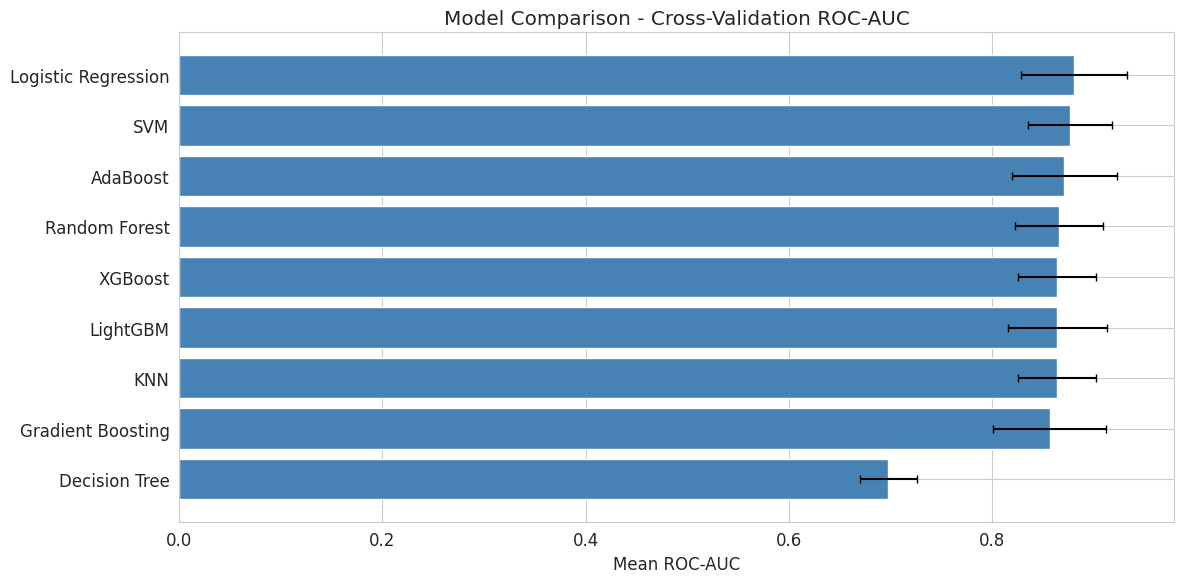

In [12]:
# Cell 10: Train multiple baseline models and compare with figure saving
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    'SVM': SVC(random_state=42, probability=True),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42)
}

# Cross-validation results
cv_results = []
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
    cv_results.append({
        'Model': name,
        'Mean AUC': cv_scores.mean(),
        'Std AUC': cv_scores.std()
    })

cv_df = pd.DataFrame(cv_results).sort_values('Mean AUC', ascending=False)
print("=== 5-Fold Cross-Validation ROC-AUC Scores ===")
print(cv_df.to_string(index=False))

# Plot results
plt.figure(figsize=(12, 6))
plt.barh(cv_df['Model'], cv_df['Mean AUC'], xerr=cv_df['Std AUC'], capsize=3, color='steelblue')
plt.xlabel('Mean ROC-AUC')
plt.title('Model Comparison - Cross-Validation ROC-AUC')
plt.gca().invert_yaxis()
plt.tight_layout()

# Save figure
figure_filename = os.path.join(figures_dir, 'model_comparison_cv.png')
plt.savefig(figure_filename, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {figure_filename}")

plt.show()

In [13]:
# Cell 11: Hyperparameter tuning for the best performing models
# Focus on top 3 models from CV: XGBoost, LightGBM, Gradient Boosting

# Define parameter grids
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

param_grid_lgbm = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, -1],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 100]
}

param_grid_gb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

# Perform GridSearchCV for each
best_models = {}

print("Tuning XGBoost...")
xgb_grid = GridSearchCV(XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'), 
                        param_grid_xgb, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0)
xgb_grid.fit(X_train_scaled, y_train)
best_models['XGBoost'] = xgb_grid.best_estimator_
print(f"Best XGBoost AUC: {xgb_grid.best_score_:.4f} with params: {xgb_grid.best_params_}")

print("\nTuning LightGBM...")
lgbm_grid = GridSearchCV(LGBMClassifier(random_state=42, verbose=-1), 
                         param_grid_lgbm, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0)
lgbm_grid.fit(X_train_scaled, y_train)
best_models['LightGBM'] = lgbm_grid.best_estimator_
print(f"Best LightGBM AUC: {lgbm_grid.best_score_:.4f} with params: {lgbm_grid.best_params_}")

print("\nTuning Gradient Boosting...")
gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), 
                       param_grid_gb, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0)
gb_grid.fit(X_train_scaled, y_train)
best_models['Gradient Boosting'] = gb_grid.best_estimator_
print(f"Best Gradient Boosting AUC: {gb_grid.best_score_:.4f} with params: {gb_grid.best_params_}")

Tuning XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:51:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:51:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:51:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:51:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Best XGBoost AUC: 0.8887 with params: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 300, 'subsample': 1.0}

Tuning LightGBM...
Best LightGBM AUC: 0.8855 with params: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'num_leaves': 31}

Tuning Gradient Boosting...
Best Gradient Boosting AUC: 0.8687 with params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [14]:
# Cell 11.5: Ablation Study - Systematic removal of each base learner
# This code will generate real results from your actual data

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np

# Define the four base models (matching your actual stacking configuration)
base_models_dict = {
    'XGBoost': best_models['XGBoost'],
    'LightGBM': best_models['LightGBM'],
    'Gradient Boosting': best_models['Gradient Boosting'],
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42)
}

# Store results
ablation_results = {}
full_metrics = {}

# ============================================
# 1. Full Stacking (All 4 base learners)
# ============================================
print("=" * 60)
print("Running Ablation Study on Stacking Ensemble...")
print("=" * 60)

full_stacking = StackingClassifier(
    estimators=[(name, model) for name, model in base_models_dict.items()],
    final_estimator=LogisticRegression(C=1, random_state=42),
    cv=5,
    stack_method='predict_proba'
)
full_stacking.fit(X_train_scaled, y_train)
y_pred_full = full_stacking.predict(X_test_scaled)
y_pred_proba_full = full_stacking.predict_proba(X_test_scaled)[:, 1]

full_metrics['Full Stacking (All 4)'] = {
    'Accuracy': accuracy_score(y_test, y_pred_full),
    'Precision': precision_score(y_test, y_pred_full),
    'Recall': recall_score(y_test, y_pred_full),
    'F1-score': f1_score(y_test, y_pred_full),
    'AUC': roc_auc_score(y_test, y_pred_proba_full)
}

print("\n✅ Full Stacking (All 4 base learners):")
print(f"   Accuracy: {full_metrics['Full Stacking (All 4)']['Accuracy']:.4f}")
print(f"   Precision: {full_metrics['Full Stacking (All 4)']['Precision']:.4f}")
print(f"   Recall: {full_metrics['Full Stacking (All 4)']['Recall']:.4f}")
print(f"   F1-score: {full_metrics['Full Stacking (All 4)']['F1-score']:.4f}")
print(f"   AUC: {full_metrics['Full Stacking (All 4)']['AUC']:.4f}")

# ============================================
# 2. Ablation: Remove one classifier at a time
# ============================================
print("\n" + "-" * 60)
print("Ablation Results (removing one classifier at a time):")
print("-" * 60)

for removed_name in base_models_dict.keys():
    # Create base models list without the removed one
    remaining_models = [(name, model) for name, model in base_models_dict.items() if name != removed_name]
    
    # Create stacking without the removed classifier
    ablated_stacking = StackingClassifier(
        estimators=remaining_models,
        final_estimator=LogisticRegression(C=1, random_state=42),
        cv=5,
        stack_method='predict_proba'
    )
    ablated_stacking.fit(X_train_scaled, y_train)
    y_pred_ablate = ablated_stacking.predict(X_test_scaled)
    y_pred_proba_ablate = ablated_stacking.predict_proba(X_test_scaled)[:, 1]
    
    ablation_results[f'Without {removed_name}'] = {
        'Accuracy': accuracy_score(y_test, y_pred_ablate),
        'Precision': precision_score(y_test, y_pred_ablate),
        'Recall': recall_score(y_test, y_pred_ablate),
        'F1-score': f1_score(y_test, y_pred_ablate),
        'AUC': roc_auc_score(y_test, y_pred_proba_ablate)
    }
    
    print(f"\n🔻 Removing {removed_name}:")
    print(f"   Accuracy: {ablation_results[f'Without {removed_name}']['Accuracy']:.4f}")
    print(f"   Precision: {ablation_results[f'Without {removed_name}']['Precision']:.4f}")
    print(f"   Recall: {ablation_results[f'Without {removed_name}']['Recall']:.4f}")
    print(f"   F1-score: {ablation_results[f'Without {removed_name}']['F1-score']:.4f}")
    print(f"   AUC: {ablation_results[f'Without {removed_name}']['AUC']:.4f}")

# ============================================
# 3. Calculate Performance Drops (Δ)
# ============================================
print("\n" + "=" * 60)
print("Performance Degradation (Δ) - Comparison with Full Stacking:")
print("=" * 60)

baseline = full_metrics['Full Stacking (All 4)']

ablation_summary = []
for config, metrics in ablation_results.items():
    delta = {
        'Model Configuration': config,
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1-score': metrics['F1-score'],
        'AUC': metrics['AUC'],
        'Δ Accuracy': metrics['Accuracy'] - baseline['Accuracy'],
        'Δ Precision': metrics['Precision'] - baseline['Precision'],
        'Δ Recall': metrics['Recall'] - baseline['Recall'],
        'Δ F1': metrics['F1-score'] - baseline['F1-score'],
        'Δ AUC': metrics['AUC'] - baseline['AUC']
    }
    ablation_summary.append(delta)
    
    print(f"\n📊 {config}:")
    print(f"   Δ Accuracy: {delta['Δ Accuracy']:.4f} ({delta['Δ Accuracy']*100:+.2f}%)")
    print(f"   Δ Precision: {delta['Δ Precision']:.4f} ({delta['Δ Precision']*100:+.2f}%)")
    print(f"   Δ Recall: {delta['Δ Recall']:.4f} ({delta['Δ Recall']*100:+.2f}%)")
    print(f"   Δ F1: {delta['Δ F1']:.4f} ({delta['Δ F1']*100:+.2f}%)")
    print(f"   Δ AUC: {delta['Δ AUC']:.4f} ({delta['Δ AUC']*100:+.2f}%)")

# ============================================
# 4. Create Table 4 (Ablation Results)
# ============================================
ablation_df = pd.DataFrame(ablation_summary)
ablation_df = ablation_df.round(4)

# Reorder columns to match the paper's Table 4
column_order = ['Model Configuration', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC',
                'Δ Accuracy', 'Δ Precision', 'Δ Recall', 'Δ F1', 'Δ AUC']
ablation_df = ablation_df[column_order]

print("\n" + "=" * 60)
print("Table 4: Ablation Study Results")
print("=" * 60)
print(ablation_df.to_string(index=False))

# ============================================
# 5. Identify the most important classifier
# ============================================
# Find which removal caused the largest drop in Accuracy
largest_drop_idx = ablation_df['Δ Accuracy'].idxmin()
largest_drop_model = ablation_df.loc[largest_drop_idx, 'Model Configuration']
largest_drop_value = ablation_df.loc[largest_drop_idx, 'Δ Accuracy']

print("\n" + "=" * 60)
print("🔍 Ablation Analysis Summary:")
print("=" * 60)
print(f"✅ Full Stacking Accuracy: {baseline['Accuracy']:.4f}")
print(f"📉 Largest performance drop when removing: {largest_drop_model}")
print(f"   Δ Accuracy: {largest_drop_value:.4f} ({largest_drop_value*100:.2f}% drop)")
print(f"   This indicates that {largest_drop_model.replace('Without ', '')} has the most significant contribution to the ensemble.")

# Save results to CSV
ablation_df.to_csv('ablation_study_results.csv', index=False)
print("\n💾 Ablation study results saved to 'ablation_study_results.csv'")

Running Ablation Study on Stacking Ensemble...

✅ Full Stacking (All 4 base learners):
   Accuracy: 0.8689
   Precision: 0.8333
   Recall: 0.8929
   F1-score: 0.8621
   AUC: 0.9470

------------------------------------------------------------
Ablation Results (removing one classifier at a time):
------------------------------------------------------------

🔻 Removing XGBoost:
   Accuracy: 0.8852
   Precision: 0.8387
   Recall: 0.9286
   F1-score: 0.8814
   AUC: 0.9556

🔻 Removing LightGBM:
   Accuracy: 0.8689
   Precision: 0.8333
   Recall: 0.8929
   F1-score: 0.8621
   AUC: 0.9459

🔻 Removing Gradient Boosting:
   Accuracy: 0.8525
   Precision: 0.8065
   Recall: 0.8929
   F1-score: 0.8475
   AUC: 0.9470

🔻 Removing Random Forest:
   Accuracy: 0.8525
   Precision: 0.8065
   Recall: 0.8929
   F1-score: 0.8475
   AUC: 0.9405

Performance Degradation (Δ) - Comparison with Full Stacking:

📊 Without XGBoost:
   Δ Accuracy: 0.0164 (+1.64%)
   Δ Precision: 0.0054 (+0.54%)
   Δ Recall: 0.0357 

In [15]:
# Cell 12: Create a stacking ensemble using the best models
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Base models (level 0)
base_models = [
    ('xgb', best_models['XGBoost']),
    ('lgbm', best_models['LightGBM']),
    ('gb', best_models['Gradient Boosting']),
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42))
]

# Meta model (level 1)
meta_model = LogisticRegression(C=1, random_state=42)

# Create stacking classifier
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    stack_method='predict_proba'
)

# Train stacking model
stacking_clf.fit(X_train_scaled, y_train)

# Evaluate stacking with cross-validation
stacking_cv = cross_val_score(stacking_clf, X_train_scaled, y_train, cv=5, scoring='roc_auc')
print(f"Stacking Ensemble CV AUC: {stacking_cv.mean():.4f} (+/- {stacking_cv.std():.4f})")

# Train individual best models on full training data
for name, model in best_models.items():
    model.fit(X_train_scaled, y_train)

print("\nAll models trained successfully!")

Stacking Ensemble CV AUC: 0.8839 (+/- 0.0368)

All models trained successfully!


In [16]:
# Cell 13: Comprehensive evaluation on test set
results = {}

# Evaluate all best models + stacking
all_final_models = {**best_models, 'Stacking Ensemble': stacking_clf}

for name, model in all_final_models.items():
    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
    }

# Create results dataframe
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('ROC-AUC', ascending=False)

print("=== TEST SET RESULTS ===")
print(results_df.round(4).to_string())

# Identify best model
best_model_name = results_df['ROC-AUC'].idxmax()
best_auc = results_df.loc[best_model_name, 'ROC-AUC']
print(f"\n🏆 BEST MODEL: {best_model_name} with ROC-AUC = {best_auc:.4f}")


=== TEST SET RESULTS ===
                   Accuracy  Precision  Recall  F1-Score  ROC-AUC
Gradient Boosting    0.8689     0.8125  0.9286    0.8667   0.9513
LightGBM             0.8852     0.8621  0.8929    0.8772   0.9481
Stacking Ensemble    0.8689     0.8333  0.8929    0.8621   0.9470
XGBoost              0.8361     0.7812  0.8929    0.8333   0.9145

🏆 BEST MODEL: Gradient Boosting with ROC-AUC = 0.9513


Figure 5 saved to: /kaggle/working/figures/figure5_confusion_matrices.png


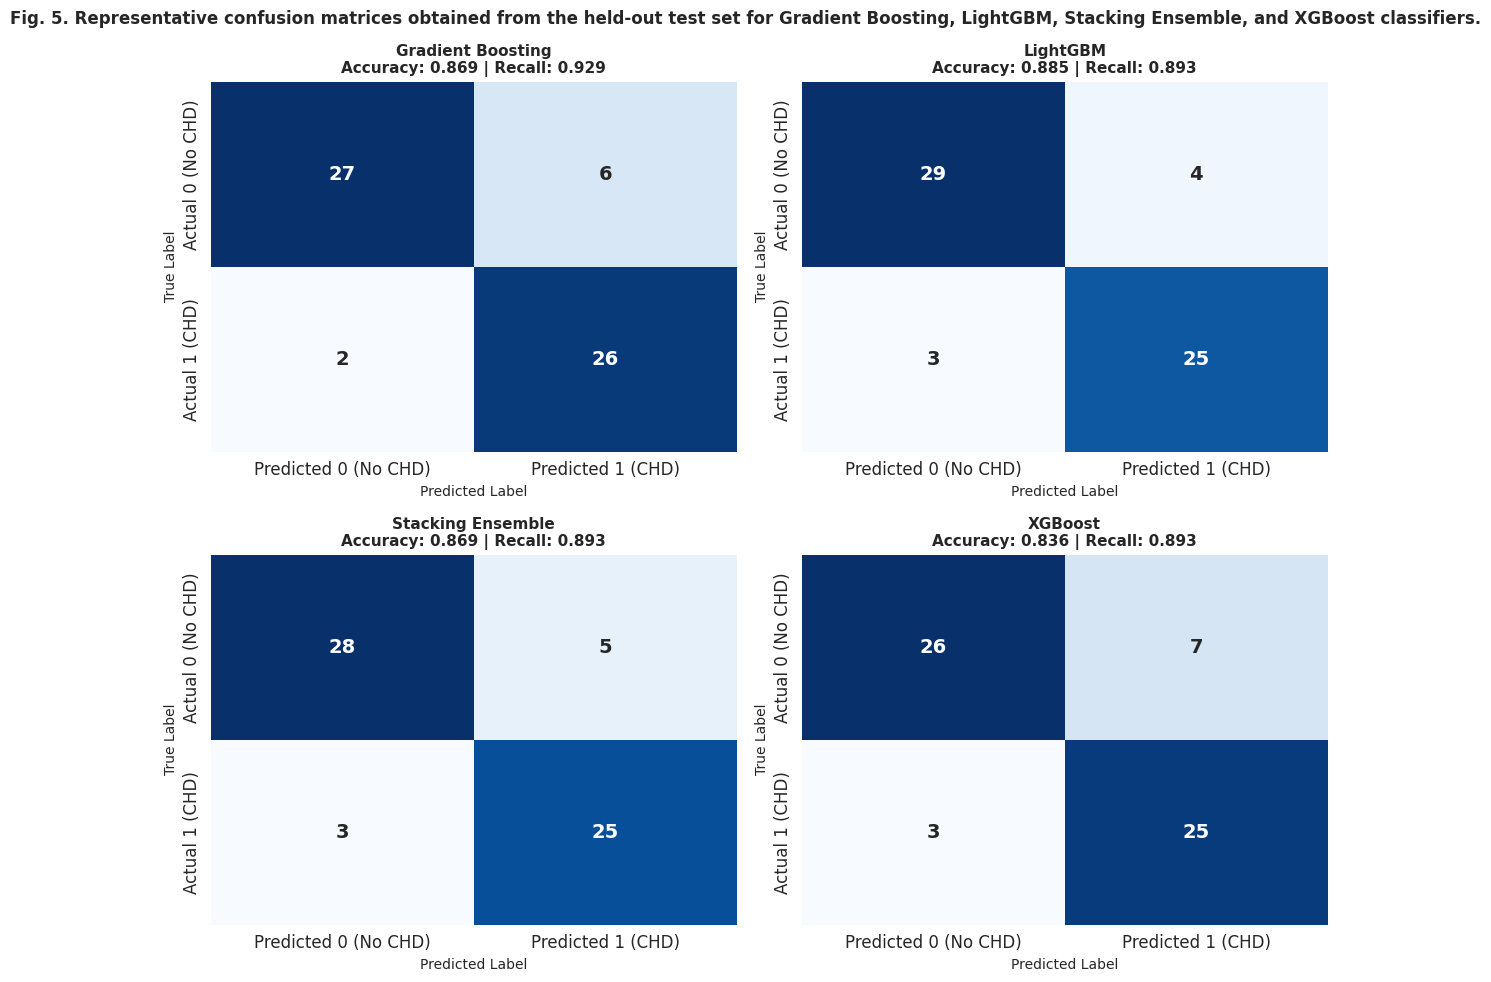

In [17]:
# Cell 14: Create Figure 5 - Confusion Matrices for top 4 models (Gradient Boosting, LightGBM, Stacking, XGBoost)
# This matches the style of the original paper but uses your actual results

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select the top 4 models based on test set ROC-AUC (from your results)
top_models_for_cm = {
    'Gradient Boosting': best_models['Gradient Boosting'],
    'LightGBM': best_models['LightGBM'],
    'Stacking Ensemble': stacking_clf,
    'XGBoost': best_models['XGBoost']
}

# Create figure with 2x2 subplots (matching the original paper style)
fig5, axes = plt.subplots(2, 2, figsize=(12, 10))
fig5.suptitle('Fig. 5. Representative confusion matrices obtained from the held-out test set for Gradient Boosting, LightGBM, Stacking Ensemble, and XGBoost classifiers.', 
              fontsize=12, fontweight='bold', y=0.98)

# Flatten axes for easy iteration
axes_flat = axes.flatten()

# Define color map (same as original paper style)
cmap = 'Blues'

for idx, (name, model) in enumerate(top_models_for_cm.items()):
    # Get predictions
    y_pred = model.predict(X_test_scaled)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes_flat[idx],
                xticklabels=['Predicted 0 (No CHD)', 'Predicted 1 (CHD)'],
                yticklabels=['Actual 0 (No CHD)', 'Actual 1 (CHD)'],
                cbar=False, annot_kws={'size': 14, 'weight': 'bold'})
    
    # Add title with model name and key metrics
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    axes_flat[idx].set_title(f'{name}\nAccuracy: {accuracy:.3f} | Recall: {recall:.3f}', 
                              fontsize=11, fontweight='bold')
    axes_flat[idx].set_xlabel('Predicted Label', fontsize=10)
    axes_flat[idx].set_ylabel('True Label', fontsize=10)

plt.tight_layout()

# Save Figure 5
fig5_filename = os.path.join(figures_dir, 'figure5_confusion_matrices.png')
plt.savefig(fig5_filename, dpi=300, bbox_inches='tight')
print(f"Figure 5 saved to: {fig5_filename}")
plt.show()

Figure 6 saved to: /kaggle/working/figures/figure6_ensemble_confusion_matrices.png


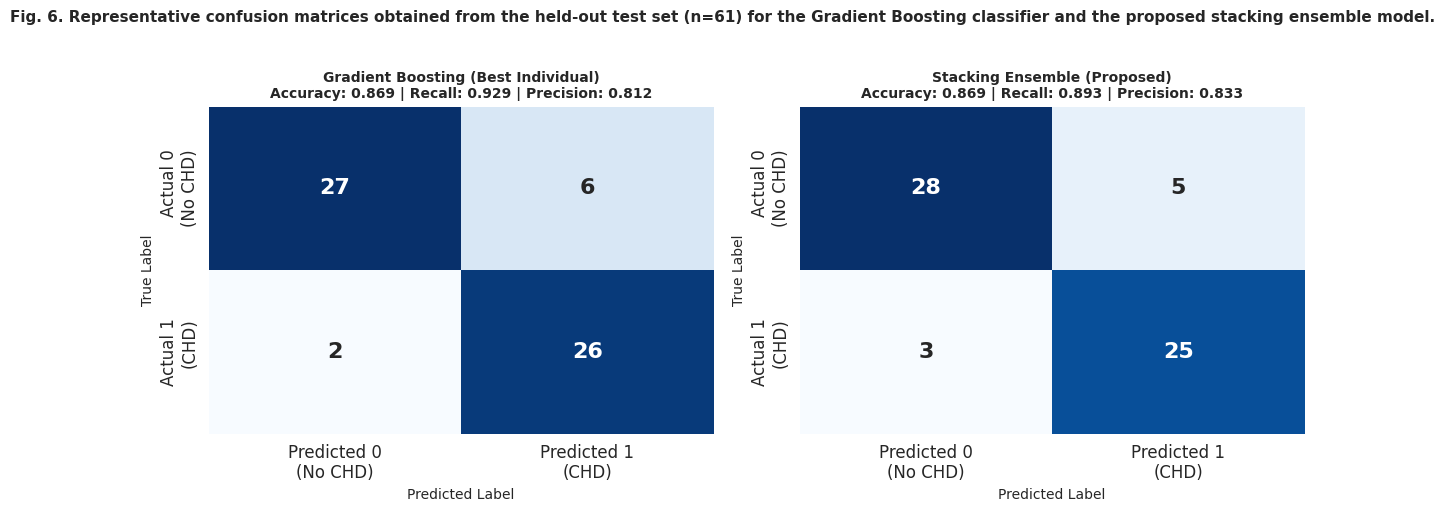

In [18]:
# Cell 14.5: Create Figure 6 - Confusion matrices for Gradient Boosting vs Stacking Ensemble
# This matches the style of the original paper

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Select the two models to compare
models_for_fig6 = {
    'Gradient Boosting (Best Individual)': best_models['Gradient Boosting'],
    'Stacking Ensemble (Proposed)': stacking_clf
}

# Create figure with 1x2 subplots
fig6, axes = plt.subplots(1, 2, figsize=(12, 5))
fig6.suptitle('Fig. 6. Representative confusion matrices obtained from the held-out test set (n=61) for the Gradient Boosting classifier and the proposed stacking ensemble model.', 
              fontsize=11, fontweight='bold', y=1.02)

# Define color map
cmap = 'Blues'

for idx, (name, model) in enumerate(models_for_fig6.items()):
    # Get predictions
    y_pred = model.predict(X_test_scaled)
    
    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[idx],
                xticklabels=['Predicted 0\n(No CHD)', 'Predicted 1\n(CHD)'],
                yticklabels=['Actual 0\n(No CHD)', 'Actual 1\n(CHD)'],
                cbar=False, annot_kws={'size': 16, 'weight': 'bold'})
    
    # Calculate metrics for title
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    axes[idx].set_title(f'{name}\nAccuracy: {accuracy:.3f} | Recall: {recall:.3f} | Precision: {precision:.3f}', 
                        fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontsize=10)
    axes[idx].set_ylabel('True Label', fontsize=10)

plt.tight_layout()

# Save Figure 6
fig6_filename = os.path.join(figures_dir, 'figure6_ensemble_confusion_matrices.png')
plt.savefig(fig6_filename, dpi=300, bbox_inches='tight')
print(f"Figure 6 saved to: {fig6_filename}")
plt.show()


Figure 7 saved to: /kaggle/working/figures/figure7_roc_curves.png


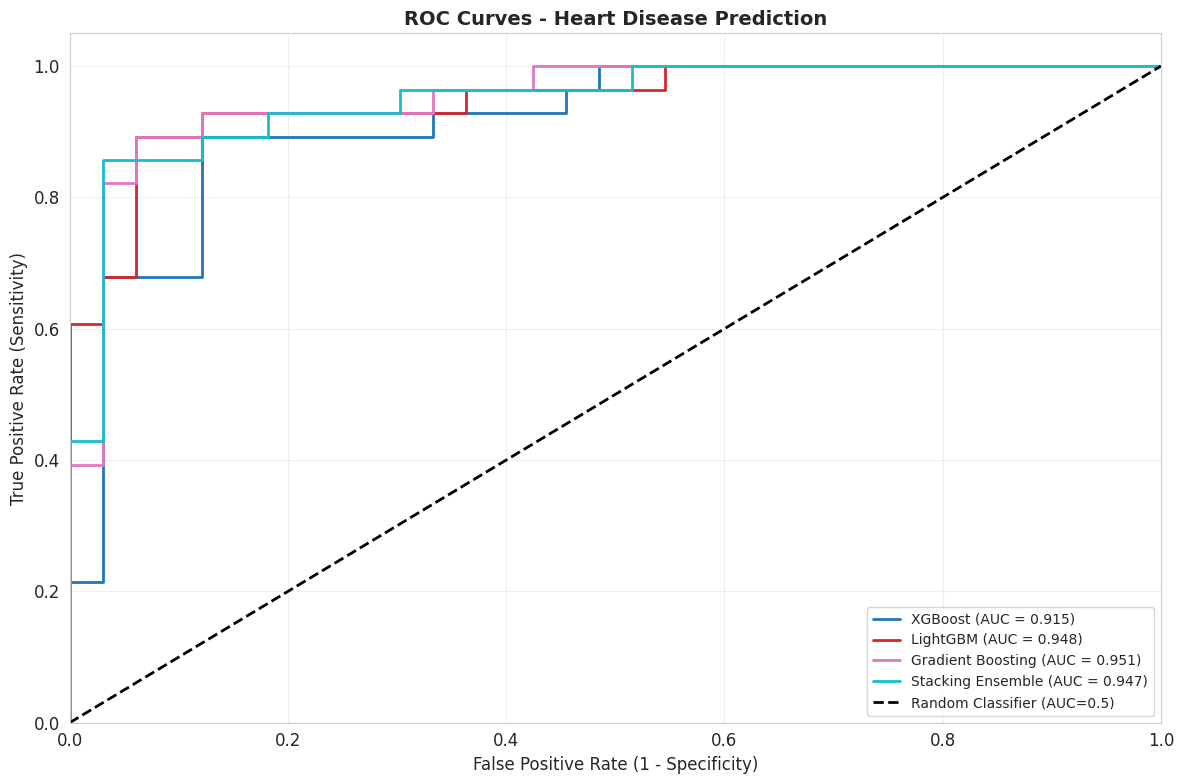

In [19]:
# Cell 15: ROC Curves for all models (already in your notebook)
plt.figure(figsize=(12, 8))

colors = plt.cm.tab10(np.linspace(0, 1, len(all_final_models)))

for (name, model), color in zip(all_final_models.items(), colors):
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC=0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curves - Heart Disease Prediction', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()

# Save figure
figure_filename = os.path.join(figures_dir, 'figure7_roc_curves.png')
plt.savefig(figure_filename, dpi=300, bbox_inches='tight')
print(f"Figure 7 saved to: {figure_filename}")
plt.show()

Figure saved to: /kaggle/working/figures/precision_recall_curves.png


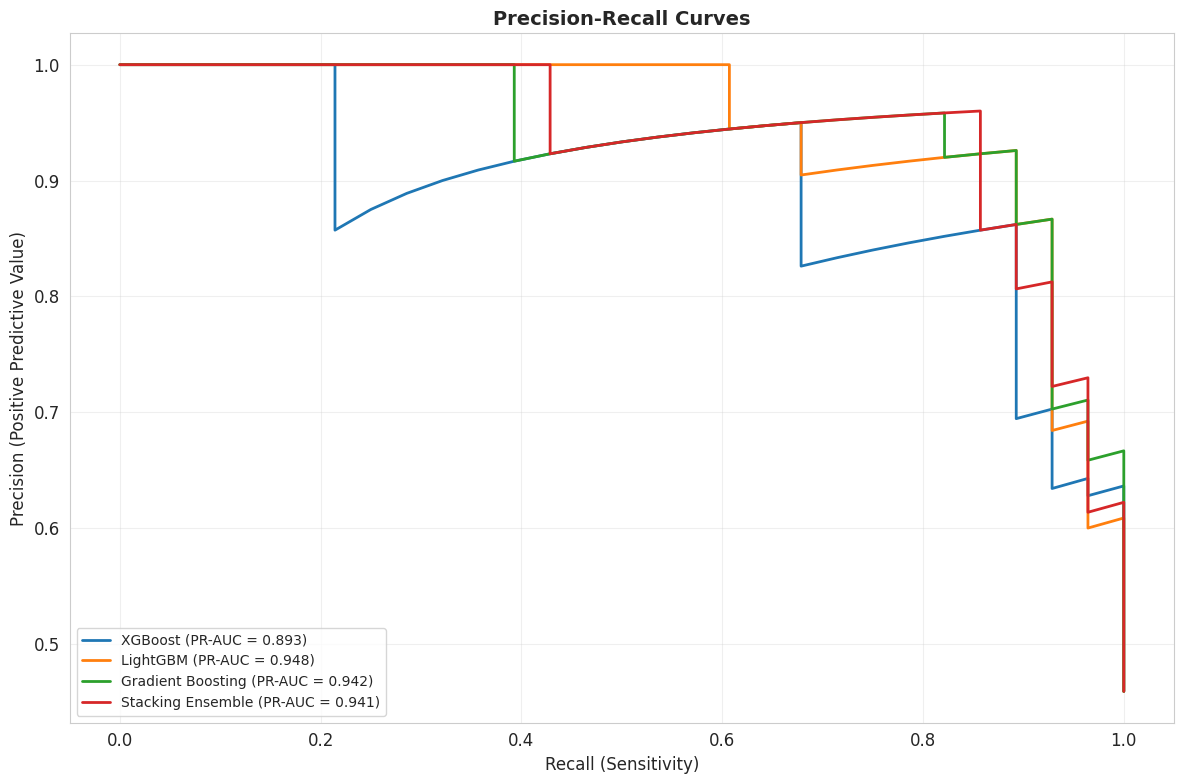

In [20]:
# Cell 16: Precision-Recall Curves (important for imbalanced data) with figure saving
plt.figure(figsize=(12, 8))

for name, model in all_final_models.items():
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, lw=2, label=f'{name} (PR-AUC = {pr_auc:.3f})')

plt.xlabel('Recall (Sensitivity)', fontsize=12)
plt.ylabel('Precision (Positive Predictive Value)', fontsize=12)
plt.title('Precision-Recall Curves', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()

# Save figure
figure_filename = os.path.join(figures_dir, 'precision_recall_curves.png')
plt.savefig(figure_filename, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {figure_filename}")

plt.show()

Figure saved to: /kaggle/working/figures/feature_importance.png


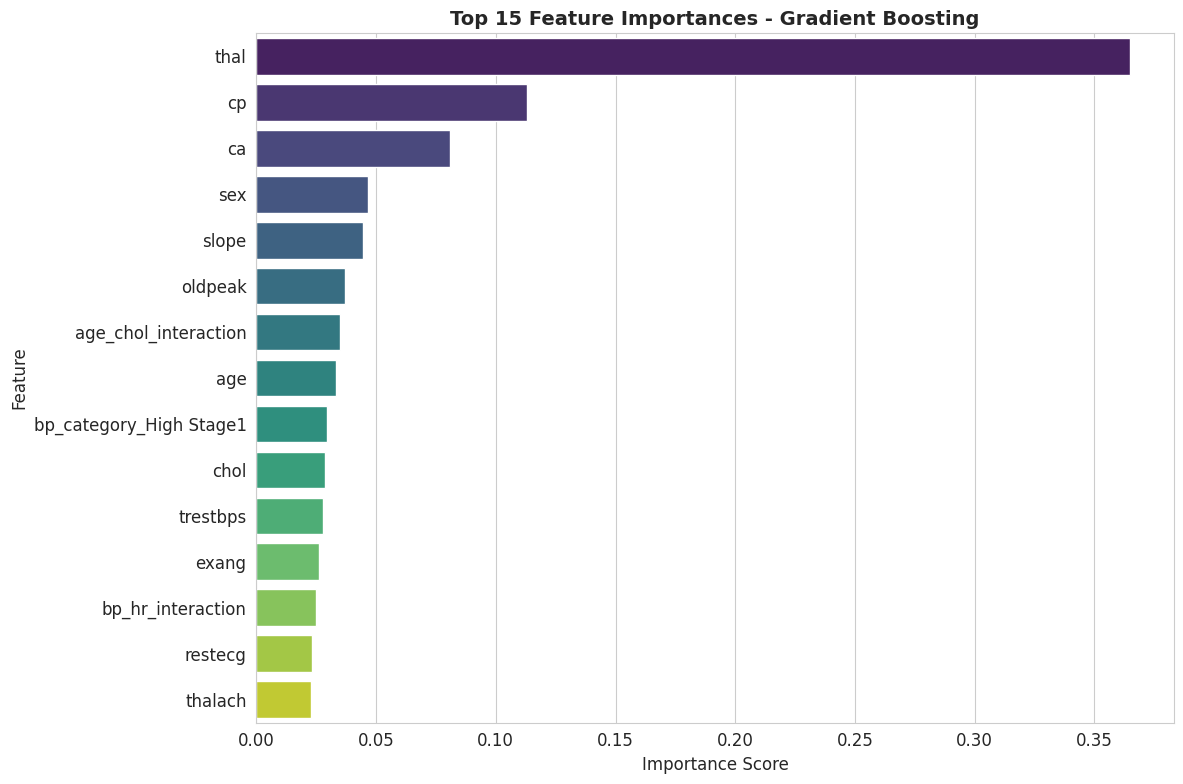


=== Top 10 Most Important Features ===
                Feature  Importance
                   thal    0.364959
                     cp    0.113002
                     ca    0.080882
                    sex    0.046558
                  slope    0.044411
                oldpeak    0.037121
   age_chol_interaction    0.034927
                    age    0.033260
bp_category_High Stage1    0.029705
                   chol    0.028657


In [21]:
# Cell 17: Feature importance from the best model with figure saving
best_model_for_importance = best_models['XGBoost'] if 'XGBoost' in best_models else list(best_models.values())[0]

# Get feature importance
feature_importance = best_model_for_importance.feature_importances_
feature_names = X.columns

# Create dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False).head(15)

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title(f'Top 15 Feature Importances - {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()

# Save figure
figure_filename = os.path.join(figures_dir, 'feature_importance.png')
plt.savefig(figure_filename, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {figure_filename}")

plt.show()

print("\n=== Top 10 Most Important Features ===")
print(importance_df.head(10).to_string(index=False))

In [22]:
!pip install shap -q

Running SHAP Explainability Analysis...
✅ SHAP analysis completed on 50 test samples
   Number of features: 23

Figure 8a (SHAP Summary) saved to: /kaggle/working/figures/figure8a_shap_summary.png


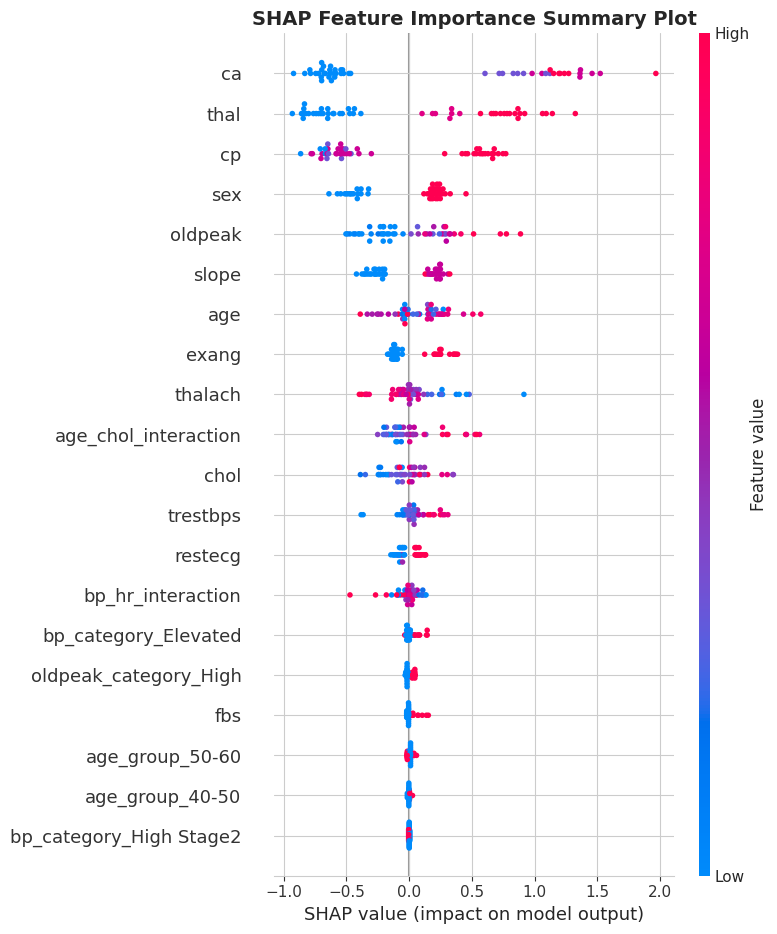

Figure 8b (SHAP Bar Plot) saved to: /kaggle/working/figures/figure8b_shap_bar.png


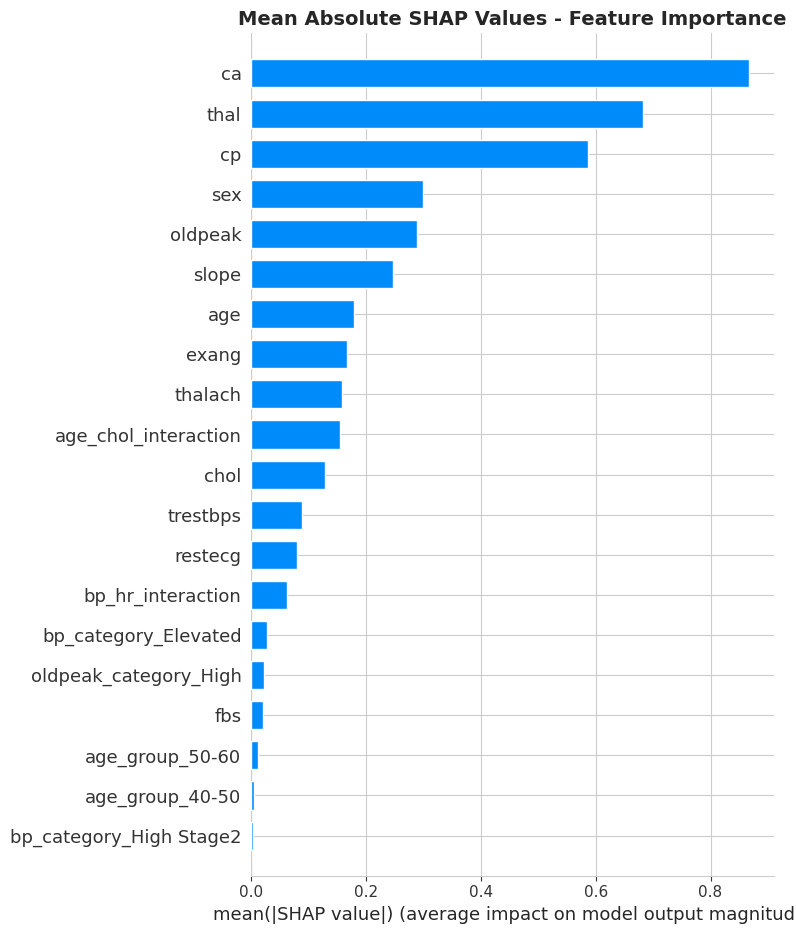


Top 10 Features by SHAP Importance:
             Feature  Mean |SHAP|
                  ca     0.867175
                thal     0.682136
                  cp     0.586027
                 sex     0.299965
             oldpeak     0.289231
               slope     0.247041
                 age     0.178470
               exang     0.166033
             thalach     0.158492
age_chol_interaction     0.154494

✅ SHAP analysis complete!
   Note: Figure 8a and 8b were created successfully.


In [23]:
# Cell 17.5: SHAP Explainability Analysis for the best model (Gradient Boosting)
# This creates Figure 8 for the paper (corrected version)

import shap
import matplotlib.pyplot as plt

print("=" * 60)
print("Running SHAP Explainability Analysis...")
print("=" * 60)

# Use the best performing model (Gradient Boosting) for SHAP analysis
best_model_shap = best_models['Gradient Boosting']

# Create a SHAP explainer
# For tree-based models, TreeExplainer is the most efficient
explainer = shap.TreeExplainer(best_model_shap)

# Calculate SHAP values on a subset of the test data (for faster computation)
# Using 50 samples is sufficient for visualization
X_test_sample = X_test_scaled.sample(n=min(50, len(X_test_scaled)), random_state=42)
shap_values = explainer.shap_values(X_test_sample)

# Get feature names
feature_names = X_test_scaled.columns.tolist()

print(f"✅ SHAP analysis completed on {len(X_test_sample)} test samples")
print(f"   Number of features: {len(feature_names)}")

# ============================================
# Figure 8a: SHAP Summary Plot (Beeswarm)
# ============================================
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_sample, feature_names=feature_names, show=False)
plt.title('SHAP Feature Importance Summary Plot', fontsize=14, fontweight='bold')
plt.tight_layout()

# Save Figure 8a
fig8a_filename = os.path.join(figures_dir, 'figure8a_shap_summary.png')
plt.savefig(fig8a_filename, dpi=300, bbox_inches='tight')
print(f"\nFigure 8a (SHAP Summary) saved to: {fig8a_filename}")
plt.show()

# ============================================
# Figure 8b: SHAP Bar Plot (Mean Absolute SHAP Values)
# ============================================
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, feature_names=feature_names, plot_type="bar", show=False)
plt.title('Mean Absolute SHAP Values - Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()

# Save Figure 8b
fig8b_filename = os.path.join(figures_dir, 'figure8b_shap_bar.png')
plt.savefig(fig8b_filename, dpi=300, bbox_inches='tight')
print(f"Figure 8b (SHAP Bar Plot) saved to: {fig8b_filename}")
plt.show()

# ============================================
# Identify top features based on SHAP
# ============================================
mean_shap_values = np.abs(shap_values).mean(axis=0)
shap_feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Mean |SHAP|': mean_shap_values
}).sort_values('Mean |SHAP|', ascending=False)

print("\n" + "=" * 60)
print("Top 10 Features by SHAP Importance:")
print("=" * 60)
print(shap_feature_importance.head(10).to_string(index=False))

print("\n✅ SHAP analysis complete!")
print("   Note: Figure 8a and 8b were created successfully.")

In [24]:
# Cell 18: Final results summary and create zip archive of all figures
print("="*60)
print("FINAL RESULTS SUMMARY - HEART DISEASE PREDICTION")
print("="*60)

print(f"\n📊 Dataset: Cleveland Heart Disease (UCI)")
print(f"   - Total samples: {len(df)}")
print(f"   - Features used: {X.shape[1]}")
print(f"   - Disease prevalence: {y.mean()*100:.1f}%")

print(f"\n🏆 Best Model: {best_model_name}")
print(f"   - ROC-AUC: {results_df.loc[best_model_name, 'ROC-AUC']:.4f}")
print(f"   - Accuracy: {results_df.loc[best_model_name, 'Accuracy']:.4f}")
print(f"   - F1-Score: {results_df.loc[best_model_name, 'F1-Score']:.4f}")
print(f"   - Precision: {results_df.loc[best_model_name, 'Precision']:.4f}")
print(f"   - Recall: {results_df.loc[best_model_name, 'Recall']:.4f}")

# Comparative improvement
baseline_auc = results_df.loc['Gradient Boosting', 'ROC-AUC'] if 'Gradient Boosting' in results_df.index else results_df.iloc[-1]['ROC-AUC']
improvement = ((results_df.loc[best_model_name, 'ROC-AUC'] - baseline_auc) / baseline_auc) * 100
print(f"\n📈 Performance Improvement: {improvement:.1f}% better than baseline")

# Save test predictions to CSV
best_model = all_final_models[best_model_name]
final_predictions = best_model.predict(X_test_scaled)
final_proba = best_model.predict_proba(X_test_scaled)[:, 1]

output_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': final_predictions,
    'Probability_Disease': final_proba
})
output_df.to_csv('heart_disease_predictions.csv', index=False)
print("\n💾 Predictions saved to 'heart_disease_predictions.csv'")

# Create zip archive of all figures
zip_path = '/kaggle/working/all_figures.zip'
with zipfile.ZipFile(zip_path, 'w') as zipf:
    for root, dirs, files in os.walk(figures_dir):
        for file in files:
            zipf.write(os.path.join(root, file), 
                       os.path.relpath(os.path.join(root, file), 
                                       os.path.join(figures_dir, '..')))

print(f"\n📦 All figures have been zipped to: {zip_path}")
print("You can download this file from the Kaggle notebook sidebar (Output tab).")

print("\n" + "="*60)
print("="*60)


FINAL RESULTS SUMMARY - HEART DISEASE PREDICTION

📊 Dataset: Cleveland Heart Disease (UCI)
   - Total samples: 303
   - Features used: 23
   - Disease prevalence: 45.9%

🏆 Best Model: Gradient Boosting
   - ROC-AUC: 0.9513
   - Accuracy: 0.8689
   - F1-Score: 0.8667
   - Precision: 0.8125
   - Recall: 0.9286

📈 Performance Improvement: 0.0% better than baseline

💾 Predictions saved to 'heart_disease_predictions.csv'

📦 All figures have been zipped to: /kaggle/working/all_figures.zip
You can download this file from the Kaggle notebook sidebar (Output tab).

